# Dataset overview: data0, data1 and data2



## Dataset Summary

| | data0 | data1 | data2 |
|---|---:|---:|---:|
| Read observations | 11,027,106 | 7,907,952 | 1,171,940 |
| Sites | 121,838 | 90,810 | 1,323 |
| Transcripts | 5,333 | 4,451 | 7 |
| Genes with available IDs | 3,852 | no gene_id column | no gene_id column |
| Labels | Binary: 0 / 1 | Binary: 0 / 1 | Seven values between 0 and 1<br>(0, 0.25, 0.50, 0.70, 0.75, 0.95, 1.00) |
| Positive sites (label 1) | 5,475 (4.49%) | 6,593 (7.26%) | Binary interpretation not established |
| Median reads per site | 47 | 40 | 814 |
| Read coverage range | 20–991 | 20–994 | 26–3,438 |



## What each row represents

Each row is a **read observation at a transcript-position site**. Multiple reads belong to the same site, and the site's sequence, coverage and annotation repeat across those rows. A site is identified by `transcript_id` and `transcript_position` within a dataset.

| Fields | Description |
|---|---|
| `transcript_id`, `transcript_position` | Identify the site |
| `sequence`, `central_5mer` | Local 7-base sequence and its central 5-base motif |
| `n_reads`, `read_idx` | Site coverage and an index for each read within the site |
| Nine signal measurements | Dwell, signal mean and signal standard deviation at three offsets: minus1, central and plus1 |
| `gene_id` | Gene annotation, available only in data0 |
| `label` | Site annotation; binary in data0/data1, decimal-valued in data2 |

- Labels describe sites, not independently labelled reads.
- Site counts represent transcript positions, not necessarily unique genomic locations.
- The datasets may contain overlapping sites, so their site counts should not be treated as counts of distinct biological sites across all three datasets.



### Preview of the dataset parquet files

In [1]:
from pathlib import Path
import pyarrow.parquet as pq

ROOT = Path.cwd()

# If the notebook starts inside notebooks/, move to the repo root.
if not (ROOT / "data/processed").is_dir():
    ROOT = ROOT.parent

if not (ROOT / "data/processed").is_dir():
    raise FileNotFoundError(
        "Cannot find data/processed. Set ROOT to your repository path."
    )

for dataset in ["data0", "data1", "data2"]:
    path = ROOT / f"data/processed/{dataset}_reads.parquet"

    parquet_file = pq.ParquetFile(path)
    batch = next(parquet_file.iter_batches(batch_size=5), None)

    print(f"\n{dataset}")
    if batch is None:
        print("The file is empty.")
    else:
        display(batch.to_pandas())


data0


,transcript_id,transcript_position,sequence,central_5mer,n_reads,read_idx,minus1_dwell,minus1_signal_sd,minus1_signal_mean,central_dwell,central_signal_sd,central_signal_mean,plus1_dwell,plus1_signal_sd,plus1_signal_mean,gene_id,label
0,ENST00000000233,244,AAGACCA,AGACC,185,0,0.00299,2.06,125.0,0.01770,10.40,122.0,0.00930,10.90,84.1,ENSG00000004059,0.0
1,ENST00000000233,244,AAGACCA,AGACC,185,1,0.00631,2.53,125.0,0.00844,4.67,126.0,0.01030,6.30,80.9,ENSG00000004059,0.0
2,ENST00000000233,244,AAGACCA,AGACC,185,2,0.00465,3.92,109.0,0.01360,12.00,124.0,0.00498,2.13,79.6,ENSG00000004059,0.0
3,ENST00000000233,244,AAGACCA,AGACC,185,3,0.00398,2.06,125.0,0.00830,5.01,130.0,0.00498,3.78,80.4,ENSG00000004059,0.0
4,ENST00000000233,244,AAGACCA,AGACC,185,4,0.00664,2.92,120.0,0.00266,3.94,129.0,0.01300,7.15,82.2,ENSG00000004059,0.0



data1


,transcript_id,transcript_position,sequence,central_5mer,n_reads,read_idx,minus1_dwell,minus1_signal_sd,minus1_signal_mean,central_dwell,central_signal_sd,central_signal_mean,plus1_dwell,plus1_signal_sd,plus1_signal_mean,gene_id,label
0,ENST00000000233,244,AAGACCA,AGACC,165,0,0.00465,2.16,127.0,0.00640,3.90,127.0,0.00797,8.75,83.7,NaN,0.0
1,ENST00000000233,244,AAGACCA,AGACC,165,1,0.02690,4.43,106.0,0.01860,10.00,123.0,0.00863,6.20,80.0,NaN,0.0
2,ENST00000000233,244,AAGACCA,AGACC,165,2,0.00432,3.10,108.0,0.01200,8.26,125.0,0.01590,2.89,78.7,NaN,0.0
3,ENST00000000233,244,AAGACCA,AGACC,165,3,0.00996,4.52,123.0,0.01750,8.51,128.0,0.00498,2.63,80.0,NaN,0.0
4,ENST00000000233,244,AAGACCA,AGACC,165,4,0.00764,2.81,124.0,0.00772,4.22,126.0,0.00474,5.84,80.9,NaN,0.0



data2


,transcript_id,transcript_position,sequence,central_5mer,n_reads,read_idx,minus1_dwell,minus1_signal_sd,minus1_signal_mean,central_dwell,central_signal_sd,central_signal_mean,plus1_dwell,plus1_signal_sd,plus1_signal_mean,gene_id,label
0,tx_id_0,0,AAAACCT,AAACC,885,0,0.01220,3.99,106.0,0.00337,4.56,102.0,0.00664,4.20,84.2,NaN,1.0
1,tx_id_0,0,AAAACCT,AAACC,885,1,0.03020,2.32,107.0,0.00443,2.36,102.0,0.00332,2.13,79.2,NaN,1.0
2,tx_id_0,0,AAAACCT,AAACC,885,2,0.00232,5.55,110.0,0.00664,7.04,99.3,0.00232,2.21,86.6,NaN,1.0
3,tx_id_0,0,AAAACCT,AAACC,885,3,0.00465,2.10,104.0,0.00996,3.90,108.0,0.00401,2.18,82.2,NaN,1.0
4,tx_id_0,0,AAAACCT,AAACC,885,4,0.02110,3.49,103.0,0.00531,3.80,101.0,0.00997,2.18,81.2,NaN,1.0


## Main findings

### data0 and data1

- **Both are highly imbalanced binary datasets.**
    - Labels are described as 0 = unmodified and 1 = modified.
    - Positives account for 4.49% of data0 and 7.26% of data1.
- **Sequence context is associated with labels.** 
    - GGACT has the highest positive fraction in both datasets: 22.58% in data0 and 21.90% in data1.
    - Other motifs have much lower positive fractions, so sequence should be considered alongside signal measurements.
- **Coverage varies widely.** 
    - Most sites have far fewer reads than the maximum. 
    - In data0, median coverage is similar between classes (47 vs 48). 
        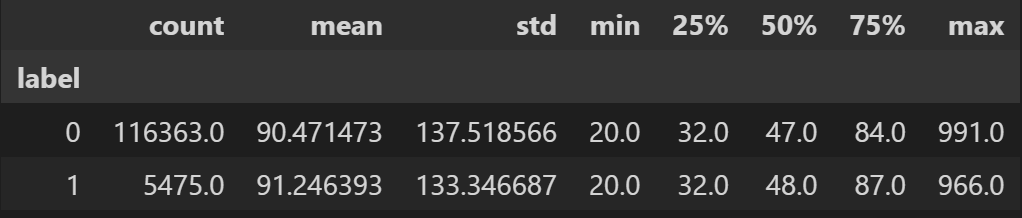
    - In data1, positives have higher median coverage (39 vs 47).
        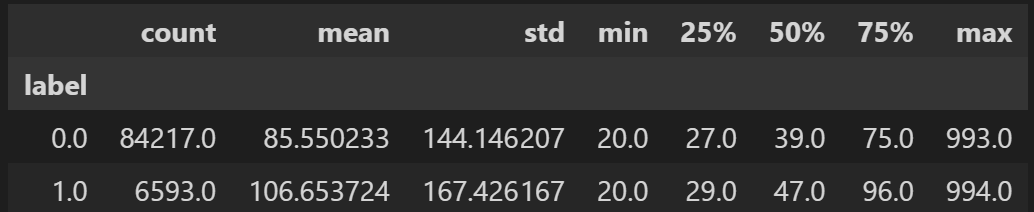

- **Signal distributions overlap.** 
    - In data0 and data1, positive sites have slightly higher median values for the three central signal summaries, but none clearly separates the classes alone.
        - data0
        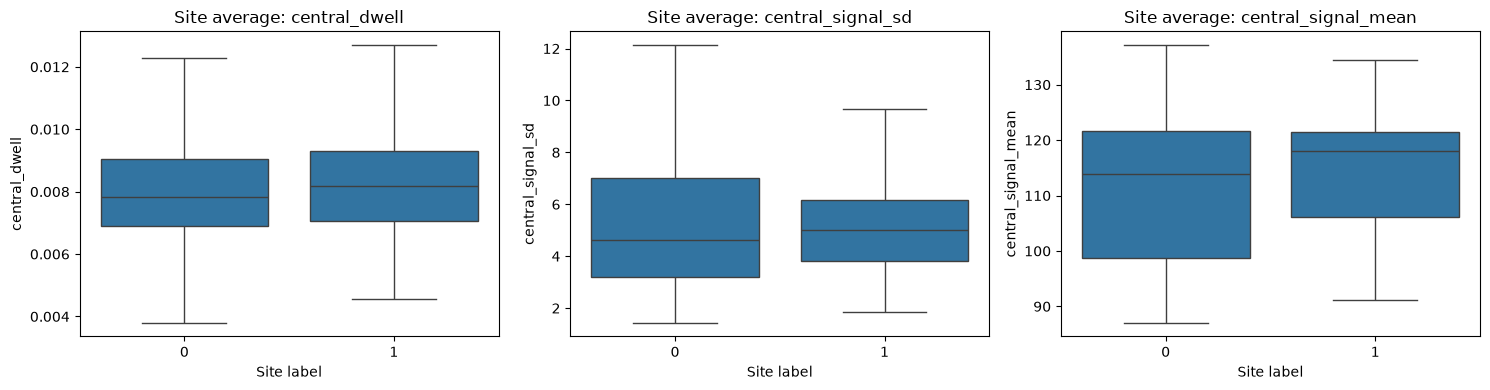
        - data1
        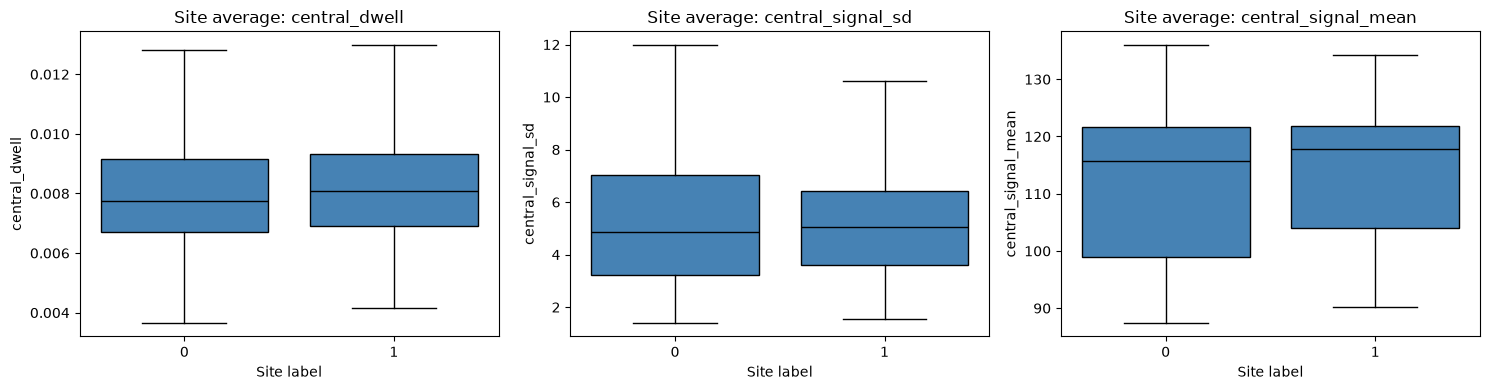

### data2

- **Has a different annotation structure.** 
    - Values are 0, 0.25, 0.50, 0.70, 0.75, 0.95 and 1.00, with 189 sites per value. 
    - Their meaning is unconfirmed; need to clarify with prof if they should not be treated as binary labels or modification probabilities.
- **Each of the seven transcripts has 189 sites and one constant annotation value.** 
    - Transcript identity and annotation value are therefore linked, making their effects difficult to distinguish.
- **Coverage is much higher:** 
    - median: 814 reads per site 
    - much higher compared to 40–47 in data0 and data1.
- **Central motif composition is equal across annotation groups.**
    - Central signal distributions still overlap substantially; observed differences cannot be separated from transcript effects.
    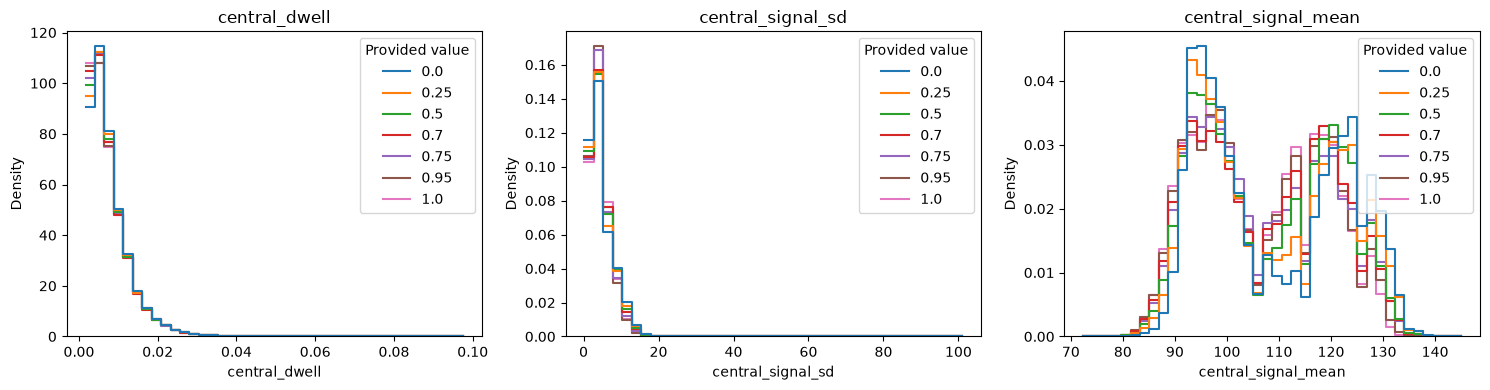



## Data quality and interpretation

- No missing values were reported in the signal, sequence, coverage or label fields. Gene IDs are entirely missing in data1 and data2.
- Site metadata and stored read counts were consistent, and no duplicate site–read keys were detected.
- All central motifs match the expected DRACH pattern, and every site has at least 20 reads.
- data2's existing binary motif summary excludes intermediate annotations. Its reported 50% positive fractions should not be used to describe data2.



## Next Steps

1. **Start with one feature row per site.** Summarise all nine signals across reads using measures such as mean, median, standard deviation and quartiles.
2. **Include sequence context.** Compare sequence-only, signal-only and combined features to establish what the signals add.
3. **Retain coverage for quality checks.** Test whether including it as a predictor helps consistently, because coverage differs across datasets and classes.
4. **Keep identifiers and annotations out of predictors.** Keep related sites together when splitting data, and check overlap between datasets to prevent leakage.
5. **Keep data2 separate from binary modelling** until its annotation meaning and experimental design are clarified.
